<a href="https://colab.research.google.com/github/sheekhaV/Agentic_AI_experiments/blob/main/Enhancing_Retrieval_with_Re_Ranking_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q sentence-transformers matplotlib

In [ ]:
import time
from sentence_transformers import SentenceTransformer, util, CrossEncoder
import numpy as np

In [ ]:
import random

def generate_synthetic_dataset():
    documents = []

    # 1. Generic monuments dataset (870 sentences)
    # These are completely unrelated to Taj Mahal to create noise
    generic_monuments = [
        "The Eiffel Tower stands majestically in Paris, France.",
        "The Great Wall of China stretches across northern China for thousands of miles.",
        "Machu Picchu is an ancient Incan citadel in Peru.",
        "The Colosseum hosted gladiatorial contests in Rome, Italy.",
        "The Statue of Liberty welcomes visitors to New York Harbor.",
        "Christ the Redeemer overlooks Rio de Janeiro from Corcovado Mountain.",
        "Stonehenge's mysterious stone circle sits in Wiltshire, England.",
        "The Sydney Opera House's distinctive shells grace Sydney Harbor.",
        "Petra's rose-red city is carved into Jordan's sandstone cliffs.",
        "Angkor Wat is the world's largest religious monument in Cambodia.",
        "The Pyramids of Giza stand on Egypt's Giza plateau.",
        "Big Ben chimes over London's Westminster district.",
        "Mount Rushmore features presidential faces carved in South Dakota.",
        "The Leaning Tower of Pisa tilts famously in Italy.",
        "Neuschwanstein Castle inspired Disney's fairy tale castle in Bavaria."
    ]

    for i in range(870):
        base = random.choice(generic_monuments)
        suffix_options = [
            f"Many tourists visit this landmark annually {i}.",
            f"The architecture is truly remarkable {i}.",
            f"Historical significance makes it a UNESCO site {i}.",
            f"Photographers love capturing its beauty {i}.",
            f"Cultural heritage is preserved here {i}.",
            f"Ancient craftsmanship is evident throughout {i}.",
            f"Millions of people admire this wonder {i}."
        ]
        documents.append(f"{base} {random.choice(suffix_options)}")

    # 2. Taj Mahal with WRONG locations (80 sentences)
    # These will confuse bi-encoders due to semantic similarity
    wrong_locations = [
        "Delhi", "Jaipur", "Varanasi", "Mumbai", "Lucknow",
        "Bhopal", "Chennai", "Hyderabad", "Kolkata", "Pune"
    ]

    wrong_templates = [
        "The Taj Mahal is located in {city}, India.",
        "You can visit the Taj Mahal in {city}.",
        "The magnificent Taj Mahal stands in {city}.",
        "Shah Jahan built the Taj Mahal in {city}.",
        "The white marble mausoleum is situated in {city}.",
        "Tourists flock to see the Taj Mahal in {city}.",
        "The ivory-white marble tomb is found in {city}.",
        "The Taj Mahal's stunning architecture graces {city}."
    ]

    for i in range(84):
        city = random.choice(wrong_locations)
        template = random.choice(wrong_templates)
        documents.append(template.format(city=city))

    # 3. Taj Mahal CORRECT answers (exactly 5 sentences)
    correct_answers = [
        "The Taj Mahal is located in Agra, India."
    ]
    documents.extend(correct_answers)

    # 4. Highly misleading/ambiguous sentences (45 sentences)
    # These are designed to be semantically similar but factually incorrect/incomplete
    misleading_templates = [
        "The Taj Mahal is in Uttar Pradesh, near Delhi.",
        "The Taj Mahal can be reached from Delhi by train.",
        "Many tourists visit Delhi to see the Taj Mahal nearby.",
        "The Taj Mahal is in northern India, close to the capital.",
        "From Delhi, the Taj Mahal is just a few hours away.",
        "The Taj Mahal stands on the banks of the Yamuna River in India.",
        "Shah Jahan's monument to love is located in northern India.",
        "The marble mausoleum sits in the state of Madhya Pradesh.",
        "This UNESCO World Heritage site is in India's heartland.",
        "The monument is situated in the Mughal architectural style in India.",
        "Built in the 17th century, this tomb is in northern India.",
        "The ivory-white structure stands somewhere in Uttar Pradesh.",
        "This symbol of love is found in the Indian subcontinent.",
        "The mausoleum complex is located in the northern part of India.",
        "The famous dome can be seen in one of India's historic cities."
    ]

    for i in range(45):
        documents.append(random.choice(misleading_templates))

    # Shuffle the entire dataset
    random.shuffle(documents)

    # Verify counts
    correct_count = sum(1 for doc in documents if "Agra" in doc)
    print(f"Total documents: {len(documents)}")
    print(f"Correct answers mentioning Agra: {correct_count}")

    return documents

# Generate the dataset
documents = generate_synthetic_dataset()

# Preview some examples
print("\n=== SAMPLE DOCUMENTS ===")
for i, doc in enumerate(documents[:5]):
    print(f"{i+1:3d}. {doc}")

print(f"\n=== VERIFICATION ===")
print(f"Total documents: {len(documents)}")

# Find and display correct answers
correct_docs = [doc for doc in documents if "Agra" in doc]
print(f"\nCorrect answers found ({len(correct_docs)}):")
for i, doc in enumerate(correct_docs, 1):
    print(f"{i}. {doc}")

# Find wrong location answers
wrong_docs = [doc for doc in documents if any(city in doc for city in ["Delhi", "Jaipur", "Varanasi", "Mumbai", "Lucknow", "Bhopal", "Chennai", "Hyderabad", "Kolkata", "Pune"]) and "Agra" not in doc]
print(f"\nWrong location examples ({len(wrong_docs)} total):")
for doc in wrong_docs[:5]:
    print(f"- {doc}")



Total documents: 1000
Correct answers mentioning Agra: 1

=== SAMPLE DOCUMENTS ===
  1. Stonehenge's mysterious stone circle sits in Wiltshire, England. Photographers love capturing its beauty 858.
  2. The magnificent Taj Mahal stands in Pune.
  3. The Taj Mahal stands on the banks of the Yamuna River in India.
  4. Petra's rose-red city is carved into Jordan's sandstone cliffs. The architecture is truly remarkable 481.
  5. The Leaning Tower of Pisa tilts famously in Italy. Photographers love capturing its beauty 287.

=== VERIFICATION ===
Total documents: 1000

Correct answers found (1):
1. The Taj Mahal is located in Agra, India.

Wrong location examples (100 total):
- The magnificent Taj Mahal stands in Pune.
- The Taj Mahal is in Uttar Pradesh, near Delhi.
- The Taj Mahal can be reached from Delhi by train.
- The white marble mausoleum is situated in Delhi.
- The Taj Mahal can be reached from Delhi by train.


In [ ]:
# Query
query = "Where is the Taj Mahal located?"

In [ ]:
#-----------------------------
# 2. Bi-encoder Retrieval
# -----------------------------
bi_encoder = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')

# Encode query and docs
query_emb = bi_encoder.encode(query, convert_to_tensor=True)
doc_embs = bi_encoder.encode(documents, convert_to_tensor=True)

# Similarity search
start_time = time.time()
cos_scores = util.cos_sim(query_emb, doc_embs)[0]
top_results = np.argpartition(-cos_scores, range(10))[0:25]
bi_time = time.time() - start_time

print("=== Bi-encoder Top 25 ===")
for idx in top_results:
    print(f"{cos_scores[idx]:.4f}\t{documents[idx]}")
print(f"Bi-encoder time: {bi_time:.4f} sec\n")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

=== Bi-encoder Top 25 ===
0.9093	The Taj Mahal is located in Lucknow, India.
0.9093	The Taj Mahal is located in Lucknow, India.
0.8971	The Taj Mahal is located in Hyderabad, India.
0.8971	The Taj Mahal is located in Hyderabad, India.
0.8947	The Taj Mahal is located in Mumbai, India.
0.8898	The Taj Mahal is located in Agra, India.
0.8894	The Taj Mahal is located in Pune, India.
0.8894	The Taj Mahal is located in Pune, India.
0.8875	The Taj Mahal is in northern India, close to the capital.
0.8875	The Taj Mahal is in northern India, close to the capital.
0.2568	The Leaning Tower of Pisa tilts famously in Italy. Historical significance makes it a UNESCO site 280.
0.3758	Angkor Wat is the world's largest religious monument in Cambodia. Ancient craftsmanship is evident throughout 85.
0.2074	The Great Wall of China stretches across northern China for thousands of miles. Millions of people admire this wonder 630.
0.3409	The Pyramids of Giza stand on Egypt's Giza plateau. Historical significanc

In [ ]:

# -----------------------------
# 3. Cross-encoder Reranking
# -----------------------------
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2',num_labels=1)

# Prepare candidate pairs (query, doc) from bi-encoder top 50
candidate_docs = [documents[idx] for idx in top_results]
pairs = [(query, doc) for doc in candidate_docs]

start_time = time.time()
cross_scores = cross_encoder.predict(pairs)
cross_time = time.time() - start_time

temperature = 0.1
import numpy as np
cross_scores = cross_scores / temperature

# Sort by score
reranked = sorted(zip(candidate_docs, cross_scores), key=lambda x: x[1], reverse=True)

print("=== Cross-encoder Reranked Top 25 ===")
for doc, score in reranked:
    print(f"{score:.4f}\t{doc}")
print(f"Cross-encoder time: {cross_time:.4f} sec\n")


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

=== Cross-encoder Reranked Top 25 ===
104.6947	The Taj Mahal is located in Agra, India.
102.5781	The Taj Mahal is located in Mumbai, India.
102.4642	The Taj Mahal is located in Lucknow, India.
102.4642	The Taj Mahal is located in Lucknow, India.
101.6095	The Taj Mahal is located in Hyderabad, India.
101.6095	The Taj Mahal is located in Hyderabad, India.
101.2131	The Taj Mahal is located in Pune, India.
101.2131	The Taj Mahal is located in Pune, India.
93.8250	The Taj Mahal is in northern India, close to the capital.
93.8250	The Taj Mahal is in northern India, close to the capital.
51.3699	The Taj Mahal can be reached from Delhi by train.
-73.0669	The famous dome can be seen in one of India's historic cities.
-77.2532	The Pyramids of Giza stand on Egypt's Giza plateau. Historical significance makes it a UNESCO site 198.
-84.1243	Angkor Wat is the world's largest religious monument in Cambodia. Ancient craftsmanship is evident throughout 85.
-88.4280	Big Ben chimes over London's Westmins

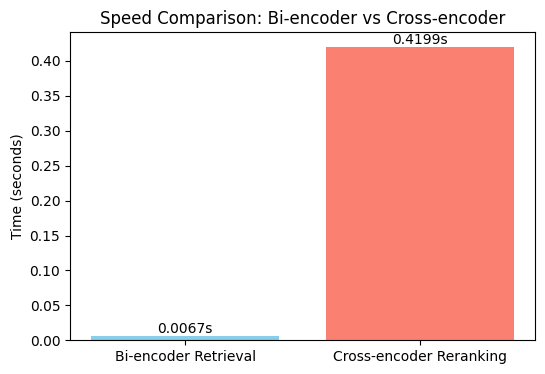

In [ ]:
import matplotlib.pyplot as plt

# Example times in seconds (replace with your measured values)
bi_time = bi_time  # Bi-encoder time
cross_time = cross_time  # Cross-encoder time

# Labels and values
methods = ["Bi-encoder Retrieval", "Cross-encoder Reranking"]
times = [bi_time, cross_time]

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(methods, times, color=["skyblue", "salmon"])
plt.ylabel("Time (seconds)")
plt.title("Speed Comparison: Bi-encoder vs Cross-encoder")

# Annotate bars with values
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{t:.4f}s", ha='center', va='bottom')

plt.show()
